<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/UNETR_3D_Segmentation_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNETR for 3D Segmentation: A Fast Tutorial

**UNETR** (Hatamizadeh et al., 2022) segments 3D medical volumes by combining two ideas:

- **Encoder = a 3D Vision Transformer.** The volume is cut into 16 × 16 × 16 patches; each patch becomes a token; 12 Transformer layers let every patch attend to every other patch, so the model sees **global context** from the first layer.
- **Decoder = a U-Net-style CNN.** Hidden states from Transformer layers **3, 6, 9, and 12** are reshaped back into 3D grids and upsampled with transposed convolutions. They are merged, like U-Net skip connections, into a full-resolution, voxel-by-voxel prediction.

```
 input volume ──► 16³ patches ──► ViT layers 1 … 3 … 6 … 9 … 12
      │                                │       │       │     │
      │                           reshape to 3D grids + upsample
      │                                ▼       ▼       ▼     ▼
      └──────── conv ──────────────►  U-Net-style CNN decoder ──► segmentation mask
```

**Data.** The **Hippocampus** task from the Medical Segmentation Decathlon: 260 brain MRI crops (about 35 × 50 × 35 voxels), labeled *background*, *anterior* hippocampus, and *posterior* hippocampus. It is a 27 MB download and trains in minutes, unlike most 3D datasets.

**Runtime.** Use a GPU: **Runtime → Change runtime type → T4 GPU**. Total time: about 5–10 minutes.

| Section | Content |
|---|---|
| 1 | Download and load the data into GPU memory |
| 2 | Build UNETR with MONAI and look inside |
| 3 | Fast training (mixed precision, whole volumes in GPU memory) |
| 4 | Visualize predictions |
| 5 | Does the transformer help? Compare with a CNN U-Net |

## 1. Data

In [ ]:
!pip install -q "monai[nibabel,einops]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00


In [ ]:
import os, time, torch, torch.nn.functional as F, matplotlib.pyplot as plt
from monai.apps import DecathlonDataset
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd, SpatialPadd
from monai.networks.nets import UNETR, UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

# UNETR uses 16-voxel patches, so every side must be a multiple of 16.
# The largest scan is 43 x 59 x 47, so we zero-pad every scan to 48 x 64 x 48.
SIZE = (48, 64, 48)
CLASSES = ["background", "anterior", "posterior"]
prep = Compose([LoadImaged(["image", "label"]), EnsureChannelFirstd(["image", "label"]),
                NormalizeIntensityd("image", nonzero=True), SpatialPadd(["image", "label"], SIZE)])

os.makedirs("data", exist_ok=True)   # download into a named folder (MONAI fails to extract into ".")

def load(section):
    ds = DecathlonDataset(root_dir="data", task="Task04_Hippocampus", section=section, download=True,
                          transform=prep, val_frac=0.2, seed=0, cache_rate=0.0)
    items = [ds[i] for i in range(len(ds))]
    x = torch.stack([d["image"].as_tensor().float() for d in items]).to(device)   # plain tensors
    y = torch.stack([d["label"].as_tensor().long() for d in items]).to(device)
    return x, y

t0 = time.time()
x_tr, y_tr = load("training")
x_va, y_va = load("validation")
print(f"train {tuple(x_tr.shape)}   val {tuple(x_va.shape)}   loaded in {time.time() - t0:.0f} s")

Task04_Hippocampus.tar: 27.1MB [00:02, 11.1MB/s]                            

2026-09-24 17:09:09,205 - INFO - Downloaded: data/Task04_Hippocampus.tar


2026-09-24 17:09:09,262 - INFO - Verified 'Task04_Hippocampus.tar', md5: 9d24dba78a72977dbd1d2e110310f31b.
2026-09-24 17:09:09,263 - INFO - Writing into directory: data.
2026-09-24 17:09:13,170 - INFO - Verified 'Task04_Hippocampus.tar', md5: 9d24dba78a72977dbd1d2e110310f31b.
2026-09-24 17:09:13,171 - INFO - File exists: data/Task04_Hippocampus.tar, skipped downloading.
2026-09-24 17:09:13,171 - INFO - Non-empty folder exists in data/Task04_Hippocampus, skipped extracting.
train (208, 1, 48, 64, 48)   val (52, 1, 48, 64, 48)   loaded in 8 s


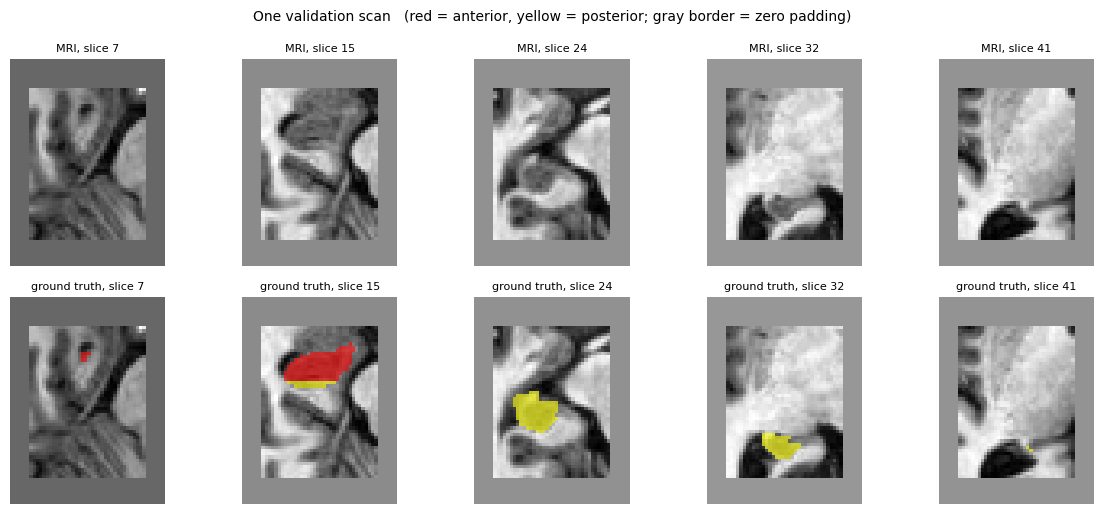

In [ ]:
def show(img, lab, pred=None, title=""):
    """Show 5 axial slices through the labeled region: MRI, ground truth, and (optionally) prediction."""
    zs = lab[0].nonzero()[:, 2]
    slices = torch.linspace(zs.min().item(), zs.max().item(), 5).long().tolist()
    rows = [("MRI", None), ("ground truth", lab)] + ([("prediction", pred)] if pred is not None else [])
    fig, ax = plt.subplots(len(rows), 5, figsize=(12, 2.6 * len(rows)))
    for r, (name, mask) in enumerate(rows):
        for c, z in enumerate(slices):
            ax[r, c].imshow(img[0, :, :, z].cpu().T, cmap="gray", origin="lower")
            if mask is not None:
                m = mask[0, :, :, z].cpu().T.float()
                ax[r, c].imshow(m.masked_fill(m == 0, float("nan")), cmap="autumn", alpha=0.6,
                                vmin=1, vmax=2, origin="lower")
            ax[r, c].set_title(f"{name}, slice {z}", fontsize=8); ax[r, c].axis("off")
    fig.suptitle(title + "   (red = anterior, yellow = posterior; gray border = zero padding)", fontsize=10)
    plt.tight_layout(); plt.show()

show(x_va[0], y_va[0], title="One validation scan")

## 2. Build UNETR and look inside

MONAI provides UNETR. We use a smaller Transformer than the paper's (hidden size 384 with 6 heads, instead of 768 with 12). That is plenty for 208 training scans and trains about 2× faster.

With 16³ patches, a 48 × 64 × 48 volume becomes 3 × 4 × 3 = **36 tokens**. That is very few, so attention is cheap here. For large CT scans, UNETR is applied to 96³ crops (216 tokens) with sliding-window inference.

In [ ]:
def make_unetr():
    return UNETR(in_channels=1, out_channels=3, img_size=SIZE, feature_size=16,
                 hidden_size=384, mlp_dim=1536, num_heads=6, norm_name="instance").to(device)

model = make_unetr()
print(f"UNETR parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M")

with torch.no_grad():
    tokens, hidden = model.vit(x_va[:1])           # the ViT encoder alone
grid = [s // 16 for s in SIZE]
print("Input volume:          ", tuple(x_va[:1].shape))
print("Tokens after ViT:      ", tuple(tokens.shape), " (batch, 36 patches, hidden size)")
print("Hidden states returned:", len(hidden), "(one per Transformer layer)")
print("Skip connections from layers 3, 6, 9, 12, each reshaped to a 3D grid:",
      tuple(hidden[2].transpose(1, 2).reshape(1, 384, *grid).shape))
print("Final output:          ", tuple(model(x_va[:1]).shape), " (batch, classes, D, H, W): one score per voxel per class")

UNETR parameters: 26.2 M
Input volume:           (1, 1, 48, 64, 48)
Tokens after ViT:       (1, 36, 384)  (batch, 36 patches, hidden size)
Hidden states returned: 12 (one per Transformer layer)
Skip connections from layers 3, 6, 9, 12, each reshaped to a 3D grid: (1, 384, 3, 4, 3)
Final output:           (1, 3, 48, 64, 48)  (batch, classes, D, H, W): one score per voxel per class


## 3. Fast training

What makes this fast:

| Trick | Why it helps |
|---|---|
| **All volumes live in GPU memory** | 260 small volumes take about 150 MB; no data loader, no disk reads |
| **Whole volumes, no patch sampling** | Each step sees complete scans |
| **Mixed precision** (`autocast` + `GradScaler`) | About 2× faster on tensor cores |
| **Dice + cross-entropy loss** | Dice handles the small foreground (about 5% of voxels); cross-entropy gives stable early gradients |
| **One-cycle learning rate + AdamW** | Fast convergence in few epochs |

We measure the **Dice score** on the validation scans: the overlap between prediction and ground truth, from 0 (no overlap) to 1 (perfect).

To keep this tutorial fast, we train for only **5 epochs** (a couple of minutes on a T4). The model will **not** have converged. In our test run, mean validation Dice was 0.65 after 1 epoch and about 0.80 after 5; in a longer run it kept rising to about 0.86 by 10–15 epochs. Increase `EPOCHS` if you have time.

In [ ]:
use_amp = device == "cuda"
loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)
dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
one_hot = lambda t: F.one_hot(t, 3).permute(0, 4, 1, 2, 3)

@torch.no_grad()
def predict(net, x, batch=8):
    net.eval()
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        return torch.cat([net(x[i:i + batch]).argmax(1, keepdim=True) for i in range(0, len(x), batch)])

def validate(net):
    dice_metric.reset()
    dice_metric(one_hot(predict(net, x_va)[:, 0]), one_hot(y_va[:, 0]))
    return dice_metric.aggregate().tolist()        # [anterior, posterior]

def train(net, epochs, batch=8, lr=1e-3, every=1):
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-5)
    steps = epochs * -(-len(x_tr) // batch)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.1)
    scaler = torch.amp.GradScaler(enabled=use_amp)
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        net.train()
        for idx in torch.randperm(len(x_tr), device=device).split(batch):
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
                loss = loss_fn(net(x_tr[idx]), y_tr[idx])
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()
        if epoch % every == 0 or epoch == epochs:
            a, p = validate(net)
            print(f"epoch {epoch:3d}   loss {loss.item():.3f}   val Dice: anterior {a:.3f}  "
                  f"posterior {p:.3f}   mean {(a + p) / 2:.3f}   {time.time() - t0:5.0f} s")
    return net

EPOCHS = 5
model = train(make_unetr(), EPOCHS)

epoch   1   loss 1.546   val Dice: anterior 0.412  posterior 0.248   mean 0.330      11 s
epoch   2   loss 1.334   val Dice: anterior 0.739  posterior 0.717   mean 0.728      15 s
epoch   3   loss 1.216   val Dice: anterior 0.782  posterior 0.758   mean 0.770      18 s
epoch   4   loss 1.173   val Dice: anterior 0.791  posterior 0.767   mean 0.779      22 s
epoch   5   loss 1.156   val Dice: anterior 0.793  posterior 0.772   mean 0.783      26 s


## 4. Visualize predictions

Below: validation scans the model never saw during training, with the ground truth and UNETR's prediction on the same slices.

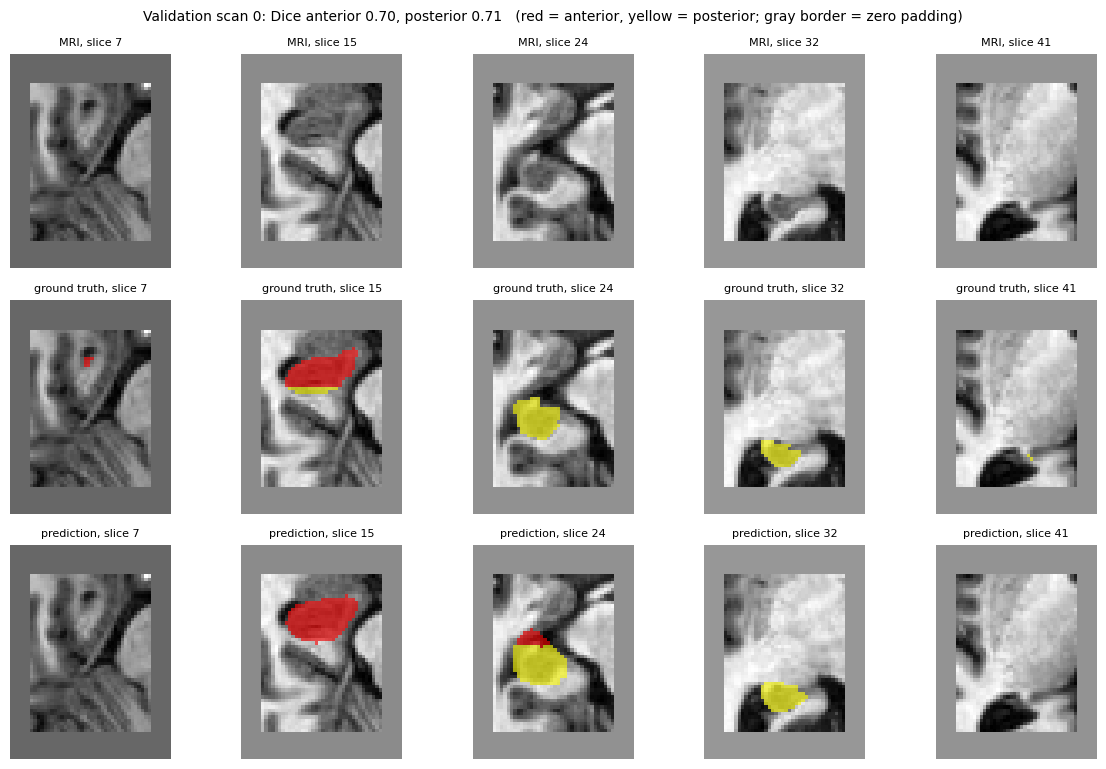

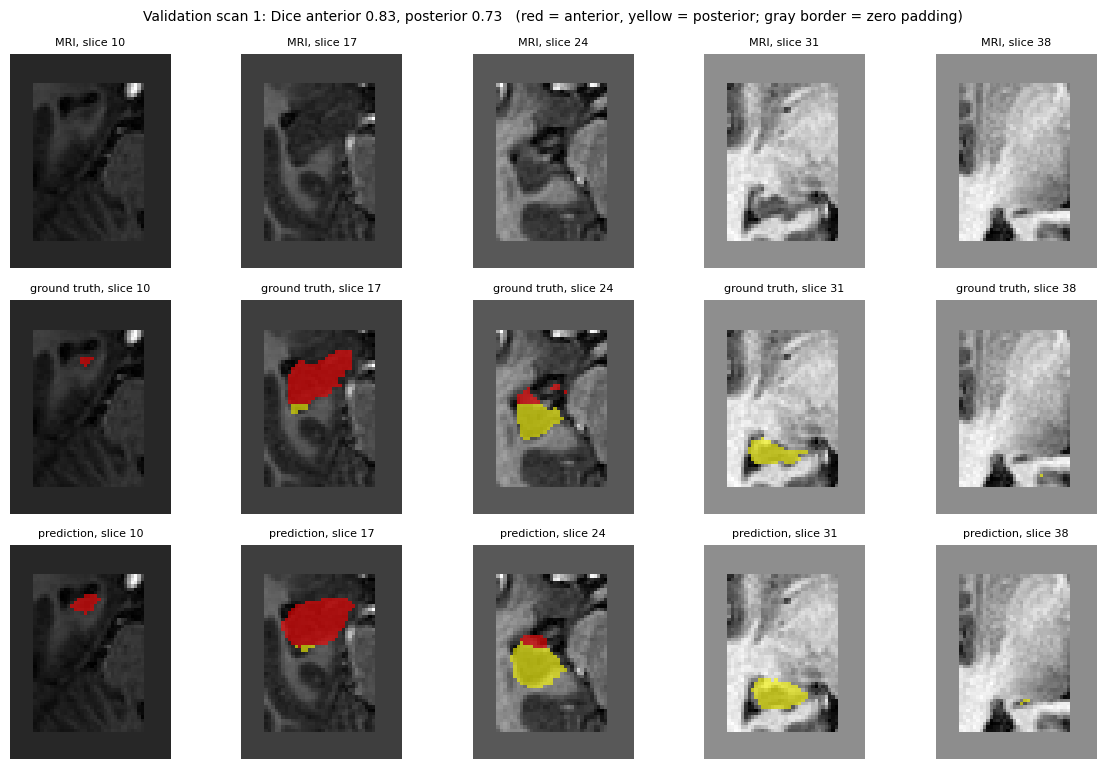

In [ ]:
pred = predict(model, x_va)
for i in [0, 1]:
    dice_metric.reset(); dice_metric(one_hot(pred[i:i + 1, 0]), one_hot(y_va[i:i + 1, 0]))
    a, p = dice_metric.aggregate().tolist()
    show(x_va[i], y_va[i], pred[i], title=f"Validation scan {i}: Dice anterior {a:.2f}, posterior {p:.2f}")

## 5. Does the transformer help? Compare with a CNN U-Net

A fair question for any Transformer model is whether a plain CNN does as well. We train MONAI's standard 3D U-Net with exactly the same data, loss, and schedule. This section is optional; it takes about as long as section 3.

In [ ]:
unet = UNet(spatial_dims=3, in_channels=1, out_channels=3, channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2), num_res_units=2, norm="instance").to(device)
print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()) / 1e6:.1f} M   "
      f"(UNETR: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M)")
unet = train(unet, EPOCHS)

U-Net parameters: 4.8 M   (UNETR: 26.2 M)
epoch   1   loss 1.541   val Dice: anterior 0.112  posterior 0.093   mean 0.102       1 s
epoch   2   loss 1.125   val Dice: anterior 0.412  posterior 0.286   mean 0.349       2 s
epoch   3   loss 0.830   val Dice: anterior 0.654  posterior 0.645   mean 0.649       3 s
epoch   4   loss 0.751   val Dice: anterior 0.712  posterior 0.711   mean 0.712       4 s
epoch   5   loss 0.735   val Dice: anterior 0.721  posterior 0.721   mean 0.721       5 s


**What to notice.** In our 5-epoch test run:

| Model | Parameters | Mean val Dice | Training time |
|---|---|---|---|
| UNETR | 26.2 M | 0.80 | 1× |
| CNN U-Net | 4.8 M | 0.82 | about 3× faster |

The plain CNN is slightly **better** and much faster here. That is a common and useful finding: on small datasets with small volumes, the local inductive bias of convolutions is hard to beat. Transformer encoders such as UNETR and Swin UNETR tend to pay off with **more data**, **larger volumes** (where long-range context matters), and **self-supervised pretraining**. Always compare against a strong CNN baseline.

## Key ideas

| Concept | Meaning |
|---|---|
| ViT encoder | Patches → tokens → self-attention; every patch sees the whole volume from layer 1 |
| Multi-level skips | Hidden states of layers 3, 6, 9, 12 are reshaped to 3D grids and upsampled into the decoder |
| CNN decoder | Recovers voxel-level detail that 16³ patches lose |
| Dice + CE loss | Standard for segmentation with a small foreground |
| Patch size vs. resolution | 16³ patches are coarse; the decoder and the input-level skip restore fine detail |

## Next steps

- **Swin UNETR**: replaces the plain ViT with a hierarchical Swin Transformer (windowed attention at several resolutions). It is usually more accurate and scales to larger volumes. In MONAI: `from monai.networks.nets import SwinUNETR`.
- **Large scans** (e.g., CT of the abdomen): train on random 96³ crops (`RandCropByPosNegLabeld`) and predict with `monai.inferers.sliding_window_inference`.
- **Pretrained weights**: the MONAI Model Zoo has UNETR and Swin UNETR bundles pretrained on multi-organ CT (BTCV) and brain tumors (BraTS).
- **Augmentation**: random affine transforms, intensity shifts, and elastic deformations usually add a few Dice points on small datasets.